In [102]:
#import libraries

import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) #adjust de configuration of the plots we will create



In [103]:
#read in the data

df = pd.read_csv(r'C:\Users\joaco\Desktop\Portfolio\Python Movies Project\movies.csv')

In [104]:
#look at the data
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [105]:
#check for missing data
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [106]:
#since we have a few missing values in important rows, let's fill them with the best approach
df['budget'].fillna(df['budget'].median(), inplace=True)
df['gross'].fillna(df['gross'].median(), inplace=True)
df['runtime'].fillna(df['runtime'].median(), inplace=True)
df['score'].fillna(df['score'].median(), inplace=True)
df['votes'].fillna(df['votes'].median(), inplace=True)

# Replace missing values in low-percentage categorical columns with "Unknown"
df['rating'].fillna('Unknown', inplace=True)
df['released'].fillna('Unknown', inplace=True)
df['writer'].fillna('Unknown', inplace=True)
df['star'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['company'].fillna('Unknown', inplace=True)

In [118]:
#re-check for missing data
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

name - 0.0%
rating - 0.0%
genre - 0.0%
year - 0.0%
released - 0.0%
score - 0.0%
votes - 0.0%
director - 0.0%
writer - 0.0%
star - 0.0%
country - 0.0%
budget - 0.0%
gross - 0.0%
company - 0.0%
runtime - 0.0%


In [107]:
#data types for our columns
df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [108]:
#change data types for convenience
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

In [109]:
#budget high correlation?
#company high correlation?


<function matplotlib.pyplot.show(close=None, block=None)>

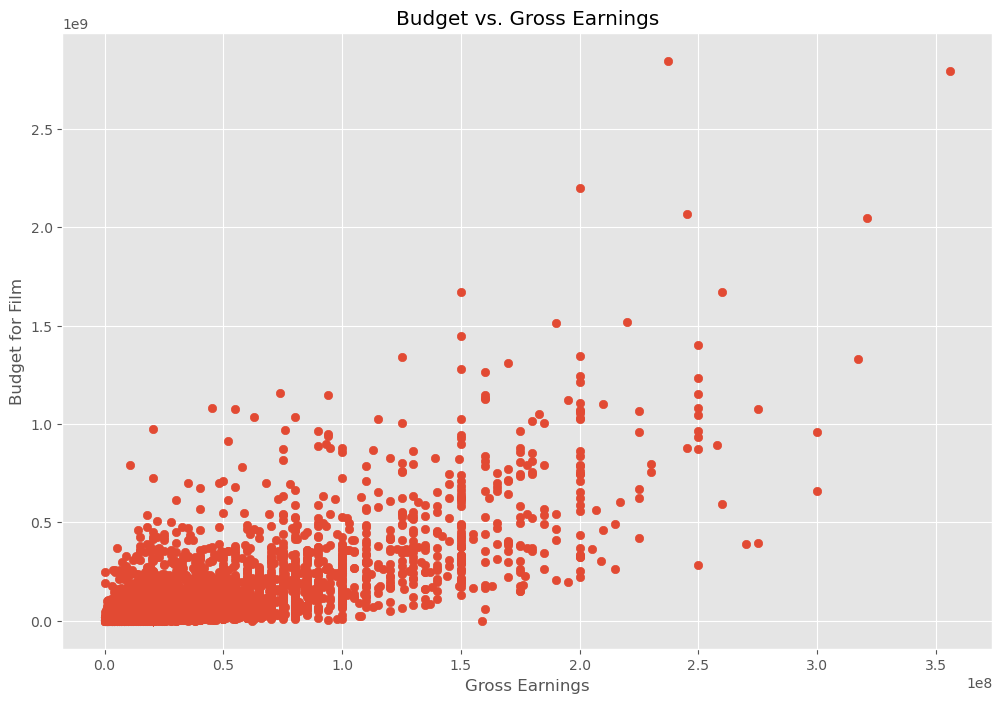

In [110]:
#scatter plot with budget vs gross

plt.scatter(x = df['budget'], y = df['gross'])
plt.title('Budget vs. Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Budget for Film')
plt.show

<AxesSubplot:xlabel='budget', ylabel='gross'>

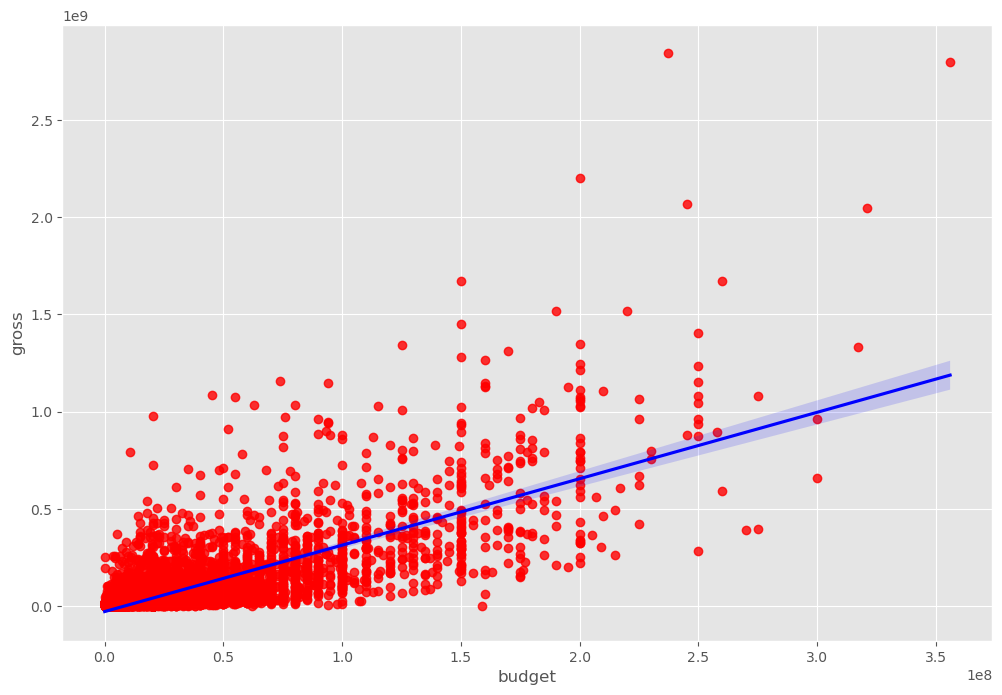

In [111]:
#plot budget vs gross using seaborn
sns.regplot(x = 'budget', y = 'gross', data = df, scatter_kws = {"color": "red"}, line_kws = {"color": "blue"})

In [112]:
#lets look at the correlation
df.corr(method = 'pearson') #pearson, kendall, spearman
#this shows that there is a high correlation between budget and gross

,year,score,votes,budget,gross,runtime
year,1.000000,0.098013,0.222573,0.291690,0.259504,0.120662
score,0.098013,1.000000,0.409157,0.061931,0.185563,0.399407
votes,0.222573,0.409157,1.000000,0.460968,0.632120,0.309151
budget,0.291690,0.061931,0.460968,1.000000,0.745881,0.273371
gross,0.259504,0.185563,0.632120,0.745881,1.000000,0.244380
runtime,0.120662,0.399407,0.309151,0.273371,0.244380,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

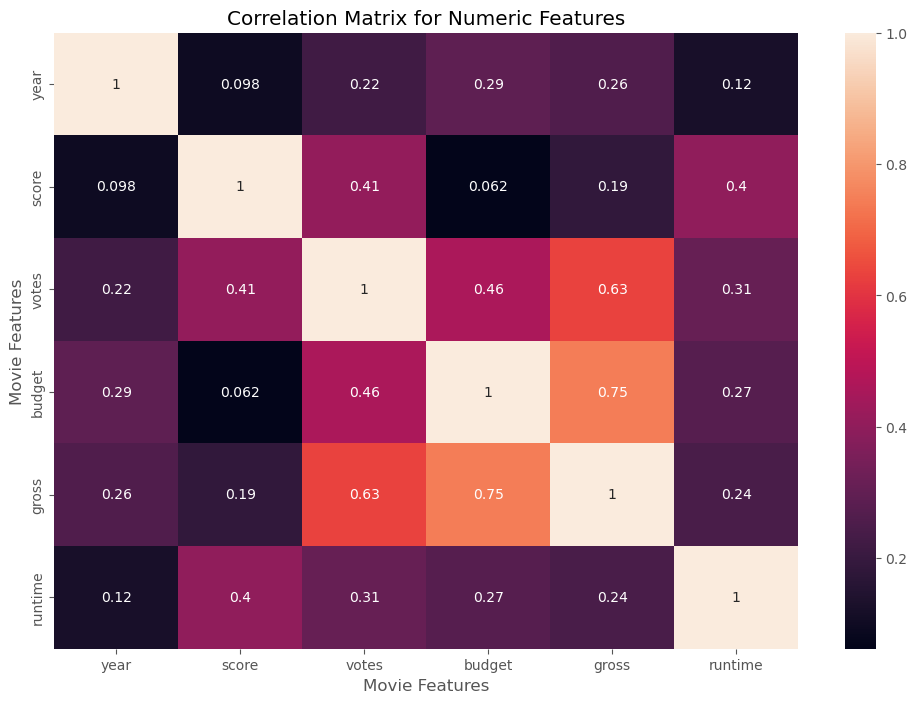

In [113]:
#display heatmap of the matrix
correlation_matrix = df.corr(method = 'pearson')
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show

In [114]:
df_numerized = df

for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,6587,6,6,1980,1705,8.4,927000.0,2589,4014,1047,54,19000000,46998772,2320,146.0
1,5573,6,1,1980,1492,5.8,65000.0,2269,1632,327,55,4500000,58853106,731,104.0
2,5142,4,0,1980,1771,8.7,1200000.0,1111,2567,1745,55,18000000,538375067,1540,124.0
3,286,4,4,1980,1492,7.7,221000.0,1301,2000,2246,55,3500000,83453539,1812,88.0
4,1027,6,4,1980,1543,7.3,108000.0,1054,521,410,55,6000000,39846344,1777,98.0
5,2109,6,10,1980,2502,6.4,123000.0,2528,4363,241,55,550000,39754601,1812,95.0
6,5574,6,0,1980,1771,7.9,188000.0,1412,838,1277,55,27000000,115229890,2281,133.0
7,4436,6,3,1980,699,8.2,330000.0,1829,1769,2240,55,18000000,23402427,631,129.0
8,5281,4,0,1980,1753,6.8,101000.0,2306,1979,877,55,54000000,108185706,883,127.0
9,6213,6,3,1980,2286,7.0,10000.0,2864,423,589,55,10000000,15795189,2272,100.0


<function matplotlib.pyplot.show(close=None, block=None)>

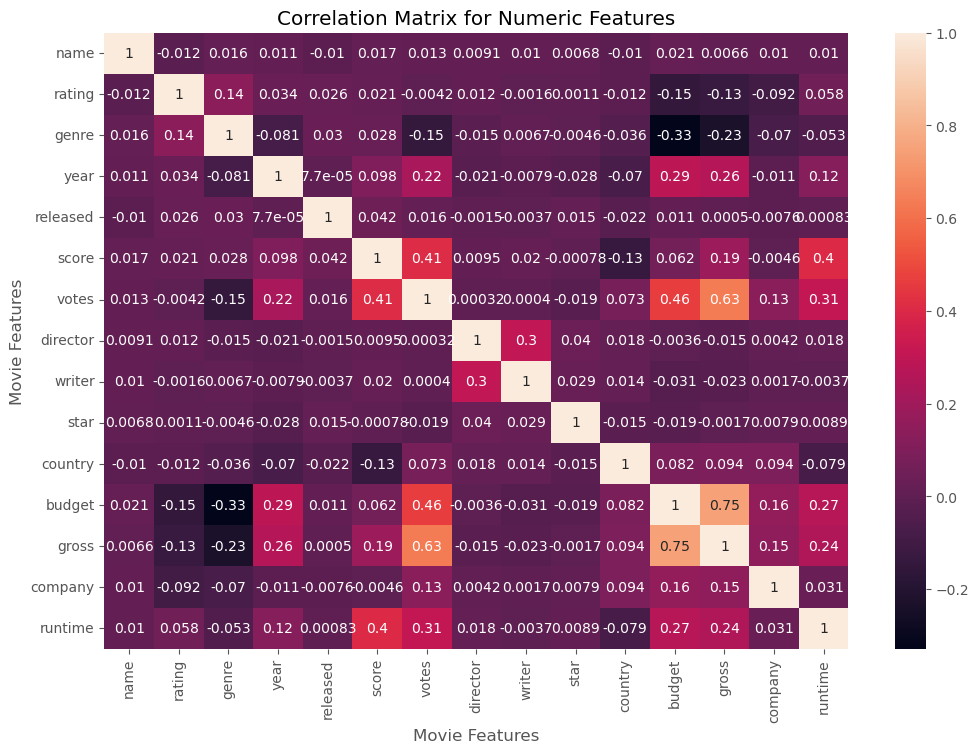

In [115]:
correlation_matrix = df_numerized.corr(method = 'pearson')
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show

In [116]:
#find correlation pairs quicker
correlation_mat = df_numerized.corr()
corr_pairs = correlation_mat.unstack().sort_values()
corr_pairs

genre     budget     -0.328484
budget    genre      -0.328484
gross     genre      -0.233385
genre     gross      -0.233385
budget    rating     -0.149686
rating    budget     -0.149686
votes     genre      -0.145291
genre     votes      -0.145291
country   score      -0.134427
score     country    -0.134427
rating    gross      -0.130747
gross     rating     -0.130747
company   rating     -0.092284
rating    company    -0.092284
year      genre      -0.081261
genre     year       -0.081261
runtime   country    -0.079230
country   runtime    -0.079230
company   genre      -0.070032
genre     company    -0.070032
country   year       -0.069590
year      country    -0.069590
runtime   genre      -0.052719
genre     runtime    -0.052719
country   genre      -0.035783
genre     country    -0.035783
budget    writer     -0.031041
writer    budget     -0.031041
year      star       -0.027912
star      year       -0.027912
gross     writer     -0.023034
writer    gross      -0.023034
released

In [117]:
#only display those pair with high correlation
high_corr = corr_pairs[(corr_pairs) > .5]
high_corr

gross     votes       0.632120
votes     gross       0.632120
budget    gross       0.745881
gross     budget      0.745881
name      name        1.000000
director  director    1.000000
gross     gross       1.000000
budget    budget      1.000000
country   country     1.000000
star      star        1.000000
writer    writer      1.000000
votes     votes       1.000000
score     score       1.000000
released  released    1.000000
year      year        1.000000
genre     genre       1.000000
rating    rating      1.000000
company   company     1.000000
runtime   runtime     1.000000
dtype: float64